# Week 3 Assignment: Word Embeddings



Submission Requirements   
	•	Code: Submit a single Jupyter Notebook containing all the Python code.
	•	In addition to model performance, students must quantitatively report vocabulary coverage—the percentage of unique IMDB tokens found in the pre-trained Word2Vec vs. GloVe models
	•	Embedding Coverage Report: You must quantitatively report the 'Vocabulary Coverage' for both pre-trained models—defined as the percentage of unique tokens from your cleaned IMDB subset that exist in the Word2Vec and GloVe dictionaries   
	•	Analysis: Include written responses to all analytical prompts in markdown cells within the notebook.    
	•	Visualization: Include all required plots and charts in the notebook.   
	•	Filename: Name the file as
			Week3_WordEmbeddings_<YourName>.pdf



In [1]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load IMDB dataset with full vocabulary
(x_train, y_train), (x_test, y_test) = imdb.load_data()

# Combine training and testing datasets to select 10,000 reviews
x_data = x_train.tolist() + x_test[:12500].tolist()
y_data = y_train.tolist() + y_test[:12500].tolist()

# Display dataset size
print("Total Reviews Selected:", len(x_train))

# Decode IMDB reviews (word index mapping provided by Keras)
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])  # Offset for special tokens

# Decode and display a sample review
print("\nSample Decoded Review:", decode_review(x_train[0]))
print("Sample Label (0=Negative, 1=Positive):", y_train[0])

# Pad sequences to ensure uniform length
# max_len = 200  # Maximum sequence length for padding
# x_data_padded = pad_sequences(x_data, maxlen=max_len, padding='post')

#print("\nPadded Review Shape:", x_data_padded.shape)

/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Total Reviews Selected: 25000

Sample Decoded Review: ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the w

**Requirement:** Create a clean_text function. While the IMDB dataset is pre-indexed, for this assignment, you must decode the reviews and re-apply cleaning (lowercase, remove punctuation, and handles) to simulate a real-world NLP pipeline before re-tokenizing.

## Part 1: Preprocessing and Embedding Preparation (30 Points)


	1.	Task:
			a.	Load and preprocess the IMDB movie reviews dataset:
				•	Clean text (lowercase, remove special characters, numbers, and URLs).
				•	Tokenize and pad sequences.
			b.	Use pre-trained Word2Vec and GloVe embeddings to represent the tokens.

	2.	Deliverable (30 points):
		•	Preprocessing Pipeline (15 points)
			•	Correct implementation of text preprocessing steps (e.g., cleaning, tokenizing, padding).
			•	Example output showing raw and preprocessed text.

		•	Embedding Preparation (15 points)
			•	Demonstrate proper loading and integration of pre-trained Word2Vec and GloVe embeddings
			•	Quantitatively report the embedding dimensions and specific percentage of IMDB tokens covered by each model
			•	Discuss the implications of **Out-of-Vocabulary (OOV)** words. If a specific film term or actor's name exists in the IMDB dataset but is missing from the pre-trained GloVe/Word2Vec dictionaries, how should your model handle this? Consider the impact on semantic representation and model performance

### Data Preprocessing/Embedding

Pre-processing will be completed using the following steps:
1. Generate a clean_text function to convert text to lowercase, remove special characters, numbers, URLs, and handles.
2. Loop through dataset. For each index, decode the review and pass the decoded string to the clean_text function. 
3. Compile each review into a new dataset for tokenization, then tokenize and pad sequences prior to storing in the new dataset.
4. Use Word2Vec and GloVe embeddings on the newly tokenized data.

#### Step 1: Generate a clean_text function to convert text to lowercase, remove special characters, numbers, URLs, and handles.

In [2]:
import re

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove handles
    text = re.sub(r'\B@\S+','',text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Rmeove emojis
    emoji_pattern = re.compile(
    "["
    "\\U0001F600-\\U0001F64F"  # emoticons
    "\\U0001F300-\\U0001F5FF"  # symbols & pictographs
    "\\U0001F680-\\U0001F6FF"  # transport & map symbols
    "\\U0001F1E0-\\U0001F1FF"  # flags (iOS)
    "\\U00002702-\\U000027B0"
    "\\U000024C2-\\U0001F251"
    "]+", flags=re.UNICODE
)
    text = emoji_pattern.sub(r'', text)

    return text

#### Step 2: Loop through dataset. For each index, decode the review and pass the decoded string to the clean_text function.

In [3]:
# Step 2:
preprocessed_x_data = []
for review in x_data:
    preprocessed_x_data.append(clean_text(decode_review(review)))

preprocessed_x_data[0]

' this film was just brilliant casting location scenery story direction everyones really suited the part they played and you could just imagine being there robert redfords is an amazing actor and now the same being director normans father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boys that played the parts of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be prai

#### Step 3: Compile each review into a new dataset for tokenization, then tokenize and pad sequences prior to storing in the new dataset. 

In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [5]:
# Step 3:

# Tokenize and pad sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(preprocessed_x_data)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(preprocessed_x_data)
padded_sequences = pad_sequences(sequences, padding='post')

print("Word Index:", word_index)
print("\nPadded Sequences:\n", padded_sequences)
print(len(preprocessed_x_data), len(padded_sequences), max([len(review.split(" ")) for review in preprocessed_x_data]), len(padded_sequences[0]))
print(preprocessed_x_data[0])
print(padded_sequences[0])

Word Index: {'the': 1, 'and': 2, 'a': 3, 'of': 4, 'to': 5, 'is': 6, 'br': 7, 'in': 8, 'it': 9, 'i': 10, 'this': 11, 'that': 12, 'was': 13, 'as': 14, 'with': 15, 'for': 16, 'movie': 17, 'but': 18, 'film': 19, 'on': 20, 'not': 21, 'you': 22, 'are': 23, 'his': 24, 'have': 25, 'be': 26, 'he': 27, 'one': 28, 'its': 29, 'all': 30, 'at': 31, 'by': 32, 'an': 33, 'they': 34, 'so': 35, 'who': 36, 'from': 37, 'like': 38, 'or': 39, 'her': 40, 'just': 41, 'about': 42, 'out': 43, 'if': 44, 'has': 45, 'some': 46, 'there': 47, 'what': 48, 'good': 49, 'more': 50, 'when': 51, 'very': 52, 'up': 53, 'no': 54, 'even': 55, 'time': 56, 'my': 57, 'she': 58, 'would': 59, 'which': 60, 'only': 61, 'really': 62, 'story': 63, 'see': 64, 'their': 65, 'were': 66, 'had': 67, 'can': 68, 'well': 69, 'me': 70, 'than': 71, 'we': 72, 'much': 73, 'bad': 74, 'get': 75, 'been': 76, 'will': 77, 'do': 78, 'people': 79, 'great': 80, 'other': 81, 'also': 82, 'into': 83, 'him': 84, 'first': 85, 'because': 86, 'how': 87, 'most': 8

#### Example showing raw vs preprocessed output.

In [6]:
raw_data = decode_review(x_data[0])
print(f'RAW DATA:\n{raw_data}\n')
print(f'PREPROCESSED DATA:\n{preprocessed_x_data[0]}\n')

RAW DATA:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and

#### Step 4: Now that the data has been preprocessed, tokenized, and padded, apply embeddings.

NOTE: The padded sequences contain 0's at the end of each index sequence. The index 0 is not present in the word index, and must be added as a custom "PAD" token, comprised of 0's in the embedding model.

In [7]:
# Add 0 to the word index
word_index['<PAD>'] = 0

Now, make a function to convert the padded data into embedding indices based on a given embedding model. A representation of the keyed vector indices is used to limit RAM requirements. If I were to store the 32 bit floating point embedding arrays associated with every token in the dataset, that would require 10000 x 1846 x 300 x 32 bits, or 22 Gigabytes, of RAM. Instead, I can store one 64 bit integer per token, reducing the RAM requirements to 10000 x 1846 x 64 bits, or 0.147 Gigabytes.

In [8]:
import numpy as np
from gensim.models import KeyedVectors

def get_embedding_indices(padded_sequences, embedding_model: KeyedVectors|dict):
    embedding_array = []
    reverse_word_index = {value: key for key, value in word_index.items()}
    for sequence in padded_sequences:
        embedding_indices = []
        for index in sequence:
            try:
                if type(embedding_model) == KeyedVectors:
                    embedding_indices.append(embedding_model.get_index(reverse_word_index[index]))
                else:
                    embedding_indices.append(list(embedding_model[reverse_word_index[index]].keys())[0])
            # Handle cases where the word is OOV
            except:
                if type(embedding_model) == KeyedVectors:
                    embedding_indices.append(embedding_model.get_index('<PAD>'))
                else:
                    embedding_indices.append(list(embedding_model['<PAD>'].keys())[0])
        embedding_array.append(embedding_indices)

    return np.array(embedding_array)

#### Demonstrate proper loading and integration of pre-trained Word2Vec and GloVe embeddings

Word2Vec Embeddings:

In [9]:
# Load Pre-Trained Word2Vec Embeddings with Gensim
import gensim.downloader as api

# Load pre-trained Word2Vec model from Gensim
word2vec_model = api.load("word2vec-google-news-300")

#Add the <PAD> token
word2vec_model['<PAD>'] = np.zeros(300, np.float32)

In [10]:
word2vec_embedding_indices = get_embedding_indices(padded_sequences, word2vec_model)

In [11]:
word2vec_embedding_indices

array([[     28,     692,      10, ..., 3000000, 3000000, 3000000],
       [    276,    3227,     276, ..., 3000000, 3000000, 3000000],
       [     28,      24, 3000000, ..., 3000000, 3000000, 3000000],
       ...,
       [   1384, 3000000,    1388, ..., 3000000, 3000000, 3000000],
       [    653,      28,      12, ..., 3000000, 3000000, 3000000],
       [     92,      11,      66, ..., 3000000, 3000000, 3000000]],
      shape=(37500, 2480))

GloVe Embeddings

In [12]:
# Load GloVe embeddings
# !wget https://nlp.stanford.edu/data/glove.6B.zip # Download the GloVe embeddings
# glove_path = "https://nlp.stanford.edu/data/glove.6B.zip" # This line is no longer needed
# Note: Download and extract the embeddings first # This comment is no longer needed

# Load the 100-dimensional embeddings and store them as {word:{index:coef}} to reduce memory requirements
glove_embeddings_index = {}
with open("data/glove.6B.100d.txt", encoding="utf-8") as f:
    for i, line in enumerate(f):
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        glove_embeddings_index[word] = {i:coefs}

In [13]:
# Determine the shape and dtype of the embeddings vector
shape = list(glove_embeddings_index['this'].values())[0].shape
embeddings_dtype = list(glove_embeddings_index['this'].values())[0].dtype

print(shape, embeddings_dtype)

(100,) float32


In [14]:
#Add the <PAD> token
glove_embeddings_index['<PAD>'] = {len(glove_embeddings_index):np.zeros(100, dtype=np.float32)}

In [15]:
GloVe_embedding_indices = get_embedding_indices(padded_sequences, glove_embeddings_index)

In [16]:
GloVe_embedding_indices

array([[    37,    319,     15, ..., 400000, 400000, 400000],
       [   365,   3017,    365, ..., 400000, 400000, 400000],
       [    37,     31,      4, ..., 400000, 400000, 400000],
       ...,
       [   193,      5,    139, ..., 400000, 400000, 400000],
       [   822,     37,     22, ..., 400000, 400000, 400000],
       [   119,      0,     68, ..., 400000, 400000, 400000]],
      shape=(37500, 2480))

#### Quantitatively report the embedding dimensions and specific percentage of IMDB tokens covered by each model

Embedding dimensions:

In [17]:
print(f'Word2Vec Embedding Dimensions:\nReviews: {word2vec_embedding_indices.shape[0]}\tTokens: {word2vec_embedding_indices.shape[1]}\tEmbedding Vector Size: {word2vec_model[word2vec_embedding_indices[0][0]].shape[0]}\n')
print(f'GloVe Embedding Dimensions:\nReviews: {GloVe_embedding_indices.shape[0]}\tTokens: {GloVe_embedding_indices.shape[1]}\tEmbedding Vector Size: {len(list(glove_embeddings_index[list(glove_embeddings_index.keys())[0]].values())[0])}\n')

Word2Vec Embedding Dimensions:
Reviews: 37500	Tokens: 2480	Embedding Vector Size: 300

GloVe Embedding Dimensions:
Reviews: 37500	Tokens: 2480	Embedding Vector Size: 100



Token Coverage:

In [18]:
word2vec_tokens = set(word_index.keys())
word2vec_tokens_covered = []
for token in list(word2vec_tokens):
    try:
        word2vec_model[token]
        word2vec_tokens_covered.append(1)
    except:
        word2vec_tokens_covered.append(0)

print(f'Word2Vec percent coverage of IMDB tokens: {(sum(word2vec_tokens_covered)/len(word2vec_tokens_covered))*100:.2f}%')

Word2Vec percent coverage of IMDB tokens: 62.90%


In [19]:
glove_tokens = set(word_index.keys())
glove_tokens_covered = []
for token in list(glove_tokens):
    try:
        glove_embeddings_index[token]
        glove_tokens_covered.append(1)
    except:
        glove_tokens_covered.append(0)

print(f'GloVe percent coverage of IMDB tokens: {(sum(glove_tokens_covered)/len(glove_tokens_covered))*100:.2f}%')

GloVe percent coverage of IMDB tokens: 77.01%


In [20]:
print(f'Word2Vec Vocabulary Size:{len(word2vec_model.key_to_index)}\tGloVe Vocabulary Size: {len(list(glove_embeddings_index.keys()))}')

Word2Vec Vocabulary Size:3000001	GloVe Vocabulary Size: 400001


The GloVe Embeddings Model has a higher percentage of the IMDB tokens covered, which is surprising given the GloVe model is 86.7% smaller than the Word2Vec model. I suspect this specific Word2Vec model is geared more toward news headlines or articles, which might explain the disproportionate lack of coverage on the IMDB dataset.

#### Discuss the implications of **Out-of-Vocabulary (OOV)** words. If a specific film term or actor's name exists in the IMDB dataset but is missing from the pre-trained GloVe/Word2Vec dictionaries, how should your model handle this? Consider the impact on semantic representation and model performance

In this case, the method for handling OOV words was to assign them all to an embeddings vector comprised of only zeros. A better approach would probably be to remove the OOV words from the dataset, as I anticipate the model deriving erroneous relationships between words that are near the 0 axis in the high dimensional embedding space. This erosion of semantic representation will have a negative impact on prediction tasks upon training the model, especially with nearly 28% of the vocabulary being bound to the same 0-weight embedding vector in the case of Word2Vec. I intentionally treated OOV words as the "PAD" token in both embedding models with the intent that the model will learn "PAD" does not have semantic meaning relative to adjacent tokens, as the majority of "PAD" tokens are adjacent to each other. 

Another method to handle OOV words would be to fine-tune the embedding model using the novel tokens. This is something that will be explored later in the assignment. 

## Part 2: Polarity Classification Using a Simple Neural Network (40 Points)


	Task:
	1.	Build a simple feedforward neural network classifier:
		•	Input: Word embeddings (Word2Vec or GloVe).
		•	Output: Polarity classification (positive, negative, neutral).
	2.	Evaluate the model’s accuracy, precision, recall, and F1-score.

	2.	Deliverable (30 points):
		• Model Implementation (20 Points):
			•	Correct implementation of a neural network with Word2Vec and GloVe embeddings.
			•	Proper integration of embeddings into the model as input.

		•	Performance Analysis (20 Points):
			•	Report Accuracy, Precision, Recall, and F1-score
			•	Based on the lecture theory, why might Skip-Gram (local context) perform differently than GloVe (global statistics) on a sentiment task? Document the training time for both models

#### Utilize Model Evaluator

There were a few modifications made to the standard ML-style evaluator I had developed prior, primarily for the prediction format.

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_score, accuracy_score
import matplotlib.pyplot as plt

class ModelEvaluator():
    def __init__(self, fit_model):
        self.model = fit_model
    
    def eval_model(self, X_test, y_test, labels):
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.model.predict(X_test)
            
        for i in range(len(self.predictions)):
            if self.predictions[i]>=0.500:
                self.predictions[i]=1
            else:
                self.predictions[i]=0

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, true_val in enumerate(self.novel_y):
            if self.predictions[i] == 1 and true_val == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.predictions[i] == 1 and true_val == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.predictions[i] == 0 and true_val == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.predictions[i] == 0 and true_val == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_metrics(self):

        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(self.novel_y, self.predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(self.novel_y, self.predictions)

        self.accuracy = f'{accuracy_score(self.novel_y, self.predictions)*100:.2f}%'

        # Compute recall
        self.recall = self.confusion_matrix['true_positive'] / (self.confusion_matrix['true_positive'] + self.confusion_matrix['false_negative'])

        # Compute precision
        self.precision = precision_score(self.novel_y, self.predictions)

        # Compute F1-Score
        self.f1_score = f'{(2*self.precision*self.recall)/(self.precision+self.recall):.2f}'

        print(f'\nAccuracy: {self.accuracy}')
        print(f'\nRecall: {self.recall}')
        print(f'\nPrecision: {self.precision}')
        print(f'\nF1-Score: {self.f1_score}')

I need to create an embeddings matrix to capture the tokens utilized in the dataset. This will reduce the dimensionality of the input matrix and simplify the model. 

In [22]:
def create_embedding_matrix(tokenizer, embedding_model:KeyedVectors|dict, embedding_dim=300):
    vocab_size = len(tokenizer.word_index) + 1
    # This ensures that padding (index 0) and OOV words (not found) are zero-vectors
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    # Iterate through the tokenizer's vocabulary
    hits = 0
    misses = 0
    
    for word, i in tokenizer.word_index.items():
        # Try to find the word in the pre-trained model
        try:
            if type(embedding_model) == KeyedVectors:
                # For KeyedVectors, use straightforward lookup
                embedding_vector = embedding_model[word]
                embedding_matrix[i] = embedding_vector
                hits += 1
            else:
                embedding_vector = list(glove_embeddings_index[word].values())[0]
                embedding_matrix[i] = embedding_vector
                hits += 1
        except KeyError:
            # If word is not in pre-trained model, it stays as zeros (or you can randomize it)
            misses += 1
            
    print(f"Converted {hits} words ({misses} misses)")
    return embedding_matrix

#### Build a simple feedforward neural network classifier:

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Embedding, GlobalMaxPool1D, Conv1D, GlobalAveragePooling1D
from tensorflow import keras

##### Word2Vec Embeddings Based Model 

In [63]:
w2v_embedding_matrix = create_embedding_matrix(tokenizer, word2vec_model)
input_dim = w2v_embedding_matrix.shape[0]
vector_len = 300 
max_length = word2vec_embedding_indices.shape[1]   

# Define the Model
word2vec_classifier_model = Sequential([
    # The input for a given review will be a 2D array comprised of the embeddings for each token.
    Input(shape=(max_length,)),
    Embedding(input_dim=input_dim,
              output_dim=vector_len, 
              weights=[w2v_embedding_matrix],
              input_length=max_length, 
              trainable=False),   
 
    # Add a convolutional layer to extract meaningful features
    # A kernel size of 1 was selected to identify individual words that contribute most to the review sentiment
    Conv1D(filters=128, kernel_size=1, activation='relu'),
    GlobalAveragePooling1D(),
    # After a bit of experminting, this pooling function seems to lead to overfitting, which I assume is a result of individual features being selected from the 
    # convolutional layer using the Max function. Alternatively, average pooling better captures multiple features that contribute to the positive or negative sentiment.
    #GlobalMaxPool1D(), 
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
word2vec_classifier_model.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

Converted 49428 words (29148 misses)


In [64]:
X_data, y_data = padded_sequences, np.array(y_data).astype(np.float32)

In [65]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.01, patience=10, verbose=1),  
    keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.1, min_delta=0.01, min_lr=1e-10, patience=4, verbose=1, mode='auto')
]

In [ ]:
word2vec_classifier_model.fit(
    X_data,
    y_data,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2,
    callbacks=callbacks
)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7408 - loss: 0.5345 - val_accuracy: 0.8403 - val_loss: 0.4021 - learning_rate: 0.0010
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8419 - loss: 0.3810 - val_accuracy: 0.8512 - val_loss: 0.3523 - learning_rate: 0.0010
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8552 - loss: 0.3464 - val_accuracy: 0.8615 - val_loss: 0.3309 - learning_rate: 0.0010
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8625 - loss: 0.3310 - val_accuracy: 0.8640 - val_loss: 0.3203 - learning_rate: 0.0010
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8656 - loss: 0.3222 - val_accuracy: 0.8715 - val_loss: 0.3126 - learning_rate: 0.0010
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8694 - loss: 0.3125 - val_accuracy: 0.8659 - val_loss: 0.3158 - learning_rate: 0.0010
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8718 - loss: 0.

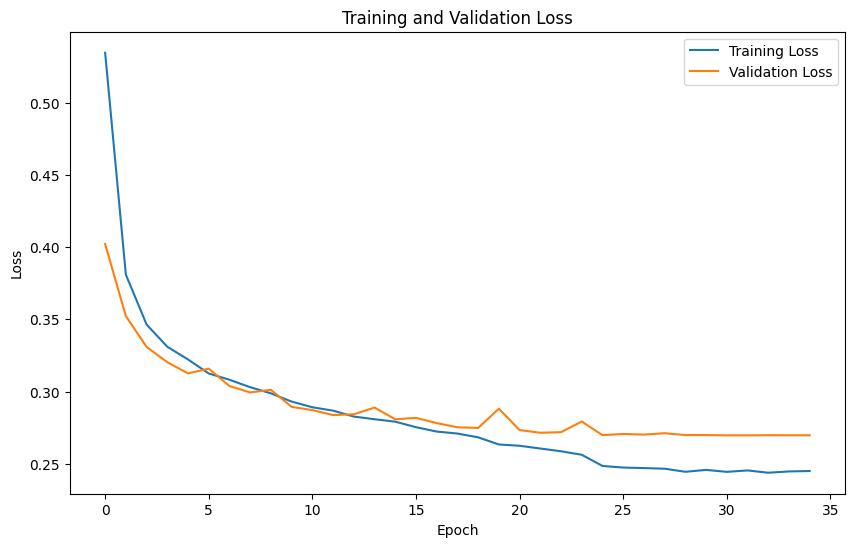

In [67]:
# Get training and validation loss values
train_loss = word2vec_classifier_model.history.history['loss']
# If you included validation data, get validation loss as well
val_loss = word2vec_classifier_model.history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

Test model on novel data:

In [68]:
novel_x = x_test[12500:]
novel_y = np.array(y_test[12500:]).astype(np.float32)

# Transform the x data with preprocessing, tokenization, and padding
preprocessed_novel_x = []
for review in novel_x:
    preprocessed_novel_x.append(clean_text(decode_review(review)))

#NOTE: The commented out lines, below, are very incorrect and you should never do this again.
#tokenizer.fit_on_texts(preprocessed_novel_x)
#novel_word_index = tokenizer.word_index
novel_sequences = tokenizer.texts_to_sequences(preprocessed_novel_x)
novel_padded_sequences = pad_sequences(novel_sequences, padding='post')

### It took me about 8 hours of helplessly flailing and changing everything about my model architecture before I realized I was incorrectly creating a new word index for my test data. I could not, for the life of me, figure out why my models would have 80%+ validation accuracy at the end of training, then drop to ~50% when I evaluated them on novel data... I have lived and I have learned.

In [69]:
test_loss, test_acc = word2vec_classifier_model.evaluate(novel_padded_sequences, novel_y)

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8919 - loss: 0.2605


391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 154us/step
Number of Negative Predictions: 6319
Number of Positive Predictions: 6181
Percent Negative Predictions: 50.552
Percent Positive Predictions: 49.448

Accuracy: 89.19%

Recall: 0.8932868904369854

Precision: 0.8928627947460042

F1-Score: 0.89


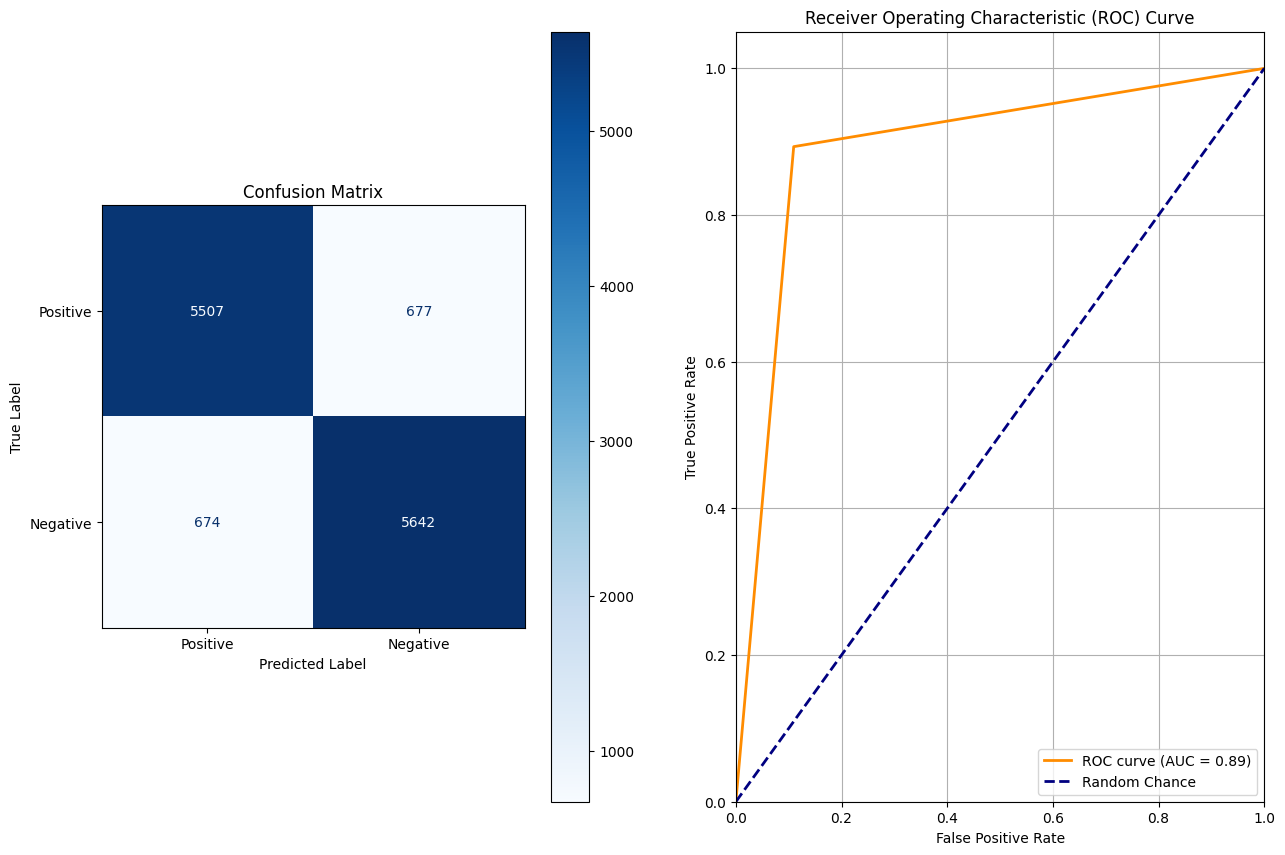

In [70]:
word2vec_eval = ModelEvaluator(word2vec_classifier_model)

word2vec_eval.eval_model(novel_padded_sequences, novel_y, labels=["Positive", "Negative"])

#### GloVe Embedding Model

In [71]:
glove_embedding_matrix = create_embedding_matrix(tokenizer, glove_embeddings_index, 100)

Converted 60508 words (18068 misses)


In [ ]:
input_dim = glove_embedding_matrix.shape[0]
vector_len = 100 
max_length = GloVe_embedding_indices.shape[1]   

# Define the Model
glove_classifier_model = Sequential([
    # The input for a given review will be a 2D array comprised of the embeddings for each token.
    Input(shape=(max_length,)),
    Embedding(input_dim=input_dim,
              output_dim=vector_len, 
              weights=[glove_embedding_matrix],
              input_length=max_length, 
              trainable=False),   
 
    # Add a convolutional layer to extract meaningful features
    # A kernel size of 1 was selected to identify individual words that contribute most to the review sentiment
    Conv1D(filters=256, kernel_size=1, activation='relu'),
    GlobalAveragePooling1D(),
    # After a bit of experminting, this pooling function seems to lead to overfitting, which I assume is a result of individual features being selected from the 
    # convolutional layer using the Max function. Alternatively, average pooling better captures multiple features that contribute to the positive or negative sentiment.
    #GlobalMaxPool1D(), 
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
glove_classifier_model.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
glove_classifier_model.fit(
    X_data,
    y_data,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2,
    callbacks=callbacks
)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6776 - loss: 0.6072 - val_accuracy: 0.7816 - val_loss: 0.5047 - learning_rate: 0.0010
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7955 - loss: 0.4639 - val_accuracy: 0.8093 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8142 - loss: 0.4239 - val_accuracy: 0.8232 - val_loss: 0.4030 - learning_rate: 0.0010
Epoch 4/100
924/938 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8172 - loss: 0.4168
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8232 - loss: 0.4065 - val_accuracy: 0.8279 - val_loss: 0.3910 - learning_rate: 0.0010
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8312 - loss: 0.3888 - val_accuracy: 0.8332 - val_loss: 0.3847 - learning_rate: 1.0000e-04
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8323 - loss:

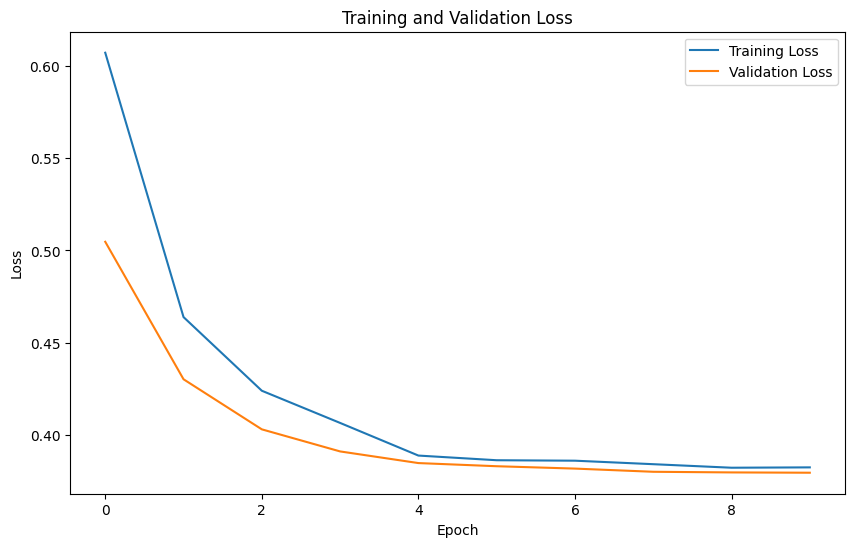

In [74]:
# Get training and validation loss values
train_loss = glove_classifier_model.history.history['loss']
# If you included validation data, get validation loss as well
val_loss = glove_classifier_model.history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [75]:
test_loss, test_acc = glove_classifier_model.evaluate(novel_padded_sequences, novel_y)

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8362 - loss: 0.3715


391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Number of Negative Predictions: 6282
Number of Positive Predictions: 6218
Percent Negative Predictions: 50.256
Percent Positive Predictions: 49.744

Accuracy: 83.62%

Recall: 0.8351804939835339

Precision: 0.8397007322508755

F1-Score: 0.84


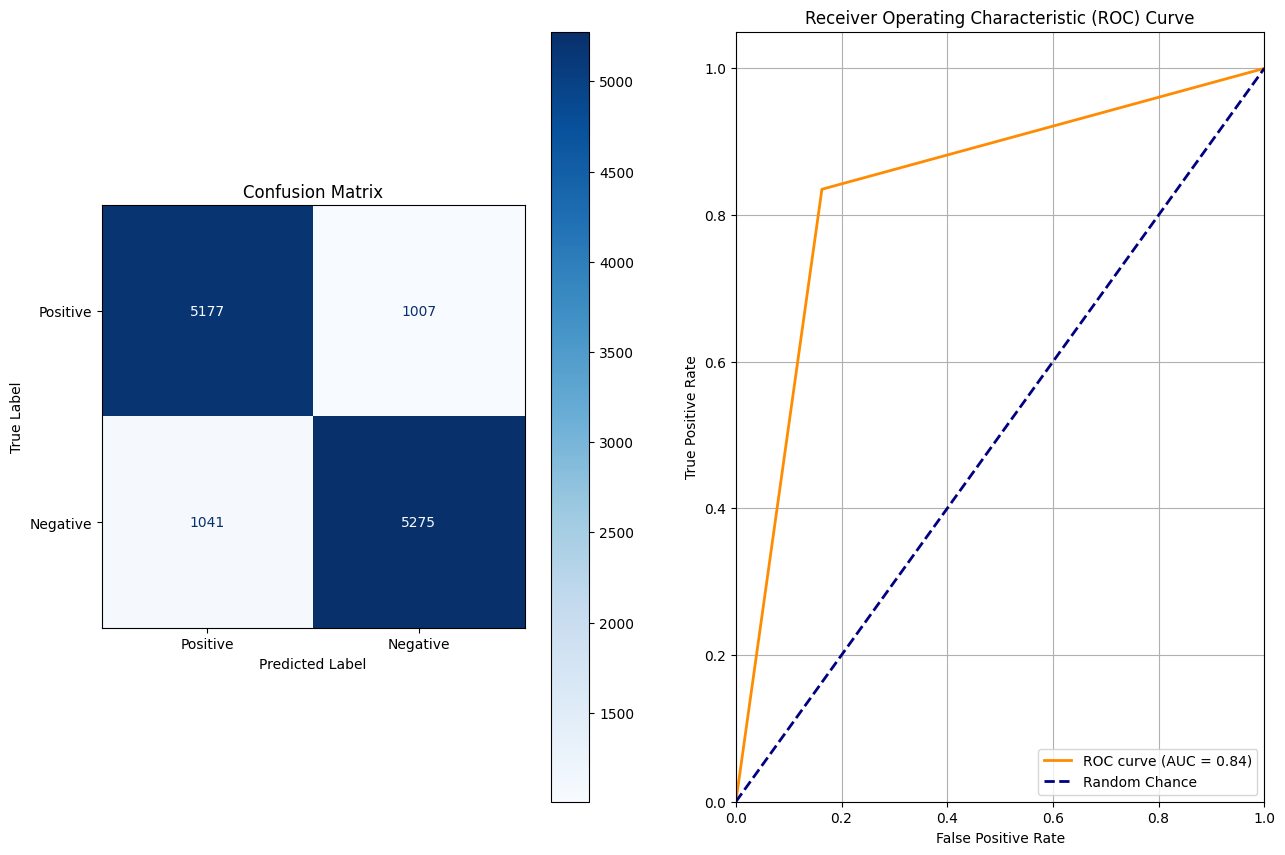

In [76]:
glove_eval = ModelEvaluator(glove_classifier_model)

glove_eval.eval_model(novel_padded_sequences, novel_y, labels=["Positive", "Negative"])

## Part 3: Fine-Tuning GloVe Embeddings (30 Points)


	1.	Task:
		•	Fine-tune the GloVe embeddings:
			•	Unfreeze the embedding layer of the model to allow updates during training.
			•	Keep all other layers frozen to focus fine-tuning on the embeddings.
			•	Re-train the classifier with fine-tuned embeddings.

	2.	Deliverable (30 points):
	•	Fine-Tuning Implementation (15 Points):
		•	Modify the embedding layer to allow training (trainable=True) while freezing all other layers.
		•	Re-train the model and provide example training output (e.g., training/validation accuracy per epoch).

	•	Performance Comparison and Analysis (15 Points):
		•	Summarize metrics (accuracy, precision, recall, F1-score) in a table comparing 'Frozen' vs. 'Fine-tuned' embeddings
		•	How does unfreezing the embedding layer allow the model to adjust pre-trained 'Global' vectors to the 'Local' sentiment nuances of movie reviews? Support your answer with a loss curve plot

In [77]:
input_dim = glove_embedding_matrix.shape[0]
vector_len = 100 
max_length = GloVe_embedding_indices.shape[1]   

# Define the Model
tuned_embeddings = Sequential([
    # The input for a given review will be a 2D array comprised of the embeddings for each token.
    Input(shape=(max_length,)),
    Embedding(input_dim=input_dim,
              output_dim=vector_len, 
              weights=[glove_embedding_matrix],
              input_length=max_length, 
              trainable=True),   
    
    # Add a convolutional layer to extract meaningful features
    # A kernel size of 1 was selected to identify individual words that contribute most to the review sentiment
    Conv1D(filters=128, kernel_size=1, activation='relu', trainable=False),
    GlobalAveragePooling1D(),
    # After a bit of experminting, this pooling function seems to lead to overfitting, which I assume is a result of individual features being selected from the 
    # convolutional layer using the Max function. Alternatively, average pooling better captures multiple features that contribute to the positive or negative sentiment.
    #GlobalMaxPool1D(), 
    Dense(128, activation='relu', trainable=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid', trainable=False)
])

# Compile the model
tuned_embeddings.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
tuned_embeddings.fit(
    X_data,
    y_data,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2,
    callbacks=callbacks
)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5955 - loss: 0.6901 - val_accuracy: 0.7053 - val_loss: 0.6872 - learning_rate: 0.0010
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6798 - loss: 0.6840 - val_accuracy: 0.7248 - val_loss: 0.6817 - learning_rate: 0.0010
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7039 - loss: 0.6785 - val_accuracy: 0.7308 - val_loss: 0.6765 - learning_rate: 0.0010
Epoch 4/100
936/938 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7129 - loss: 0.6741
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7179 - loss: 0.6728 - val_accuracy: 0.7375 - val_loss: 0.6714 - learning_rate: 0.0010
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7205 - loss: 0.6699 - val_accuracy: 0.7377 - val_loss: 0.6709 - learning_rate: 1.0000e-04
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7215 - loss:

In [79]:
tuned_embeddings.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 2480, 100)      │     7,857,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 2480, 128)      │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,602,671 (90.04 MB)

 Trainable params: 7,857,700 (29.97 MB)

 Non-trainable params: 29,569 (115.50 KB)

 Optimizer params: 15,715,402 (59.95 MB)

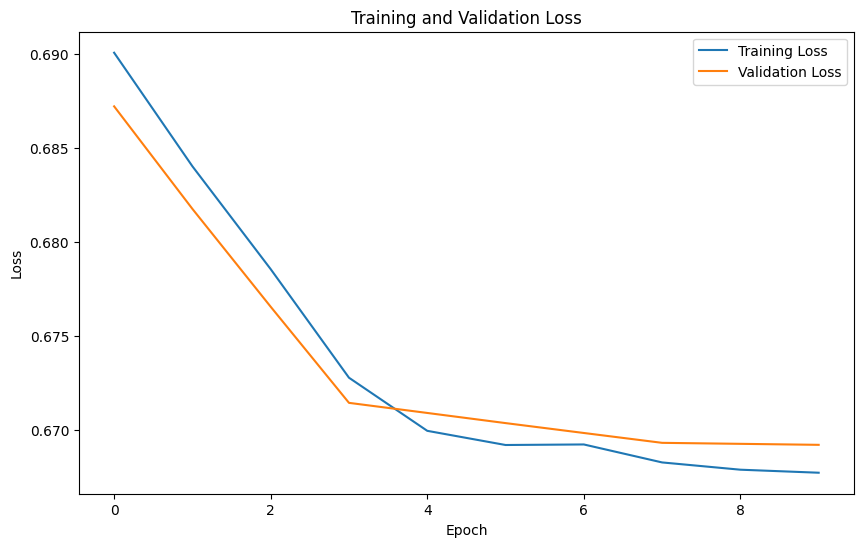

In [80]:
# Get training and validation loss values
train_loss = tuned_embeddings.history.history['loss']
# If you included validation data, get validation loss as well
val_loss = tuned_embeddings.history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [81]:
glove_classifier_with_tuned_embeddings = Sequential([
    # The input for a given review will be a 2D array comprised of the embeddings for each token.
    Input(shape=(max_length,)),
    Embedding(input_dim=input_dim,
              output_dim=vector_len, 
              weights=tuned_embeddings.layers[0].get_weights()[0],
              input_length=max_length, 
              trainable=False),   
    # Add a convolutional layer to extract meaningful features
    # A kernel size of 1 was selected to identify individual words that contribute most to the review sentiment
    Conv1D(filters=128, kernel_size=1, activation='relu'),
    GlobalAveragePooling1D(),
    # After a bit of experminting, this pooling function seems to lead to overfitting, which I assume is a result of individual features being selected from the 
    # convolutional layer using the Max function. Alternatively, average pooling better captures multiple features that contribute to the positive or negative sentiment.
    #GlobalMaxPool1D(), 
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
glove_classifier_with_tuned_embeddings.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
glove_classifier_with_tuned_embeddings.fit(
    X_data,
    y_data,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2,
    callbacks=callbacks
)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7986 - loss: 0.4546 - val_accuracy: 0.8247 - val_loss: 0.4140 - learning_rate: 0.0010
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8603 - loss: 0.3378 - val_accuracy: 0.8528 - val_loss: 0.3423 - learning_rate: 0.0010
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8733 - loss: 0.3066 - val_accuracy: 0.8633 - val_loss: 0.3172 - learning_rate: 0.0010
Epoch 4/100
931/938 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8808 - loss: 0.2950
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8813 - loss: 0.2909 - val_accuracy: 0.8721 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8877 - loss: 0.2780 - val_accuracy: 0.8741 - val_loss: 0.2995 - learning_rate: 1.0000e-04
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8888 - loss:

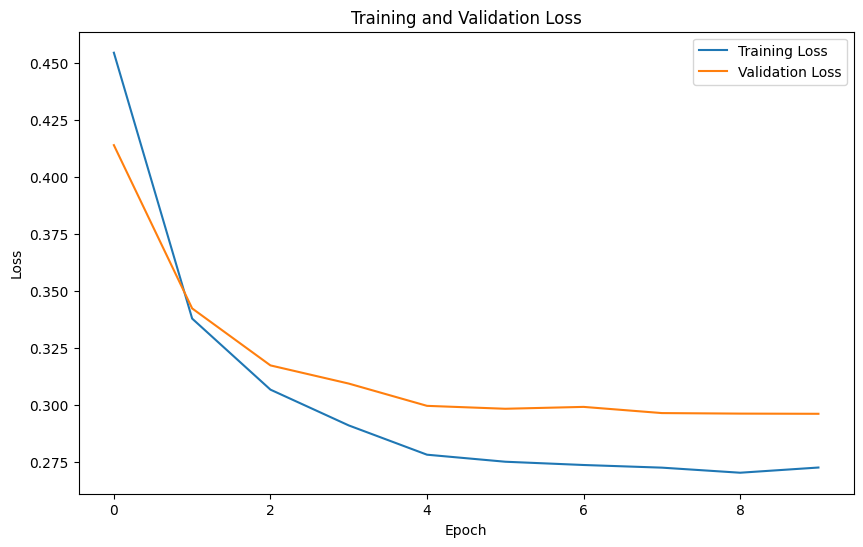

In [83]:
# Get training and validation loss values
train_loss = glove_classifier_with_tuned_embeddings.history.history['loss']
# If you included validation data, get validation loss as well
val_loss = glove_classifier_with_tuned_embeddings.history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [84]:
test_loss, test_acc = glove_classifier_with_tuned_embeddings.evaluate(novel_padded_sequences, novel_y)

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8801 - loss: 0.2859


391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Number of Negative Predictions: 6287
Number of Positive Predictions: 6213
Percent Negative Predictions: 50.296
Percent Positive Predictions: 49.704

Accuracy: 88.01%

Recall: 0.8790373654211526

Precision: 0.8830920947987911

F1-Score: 0.88


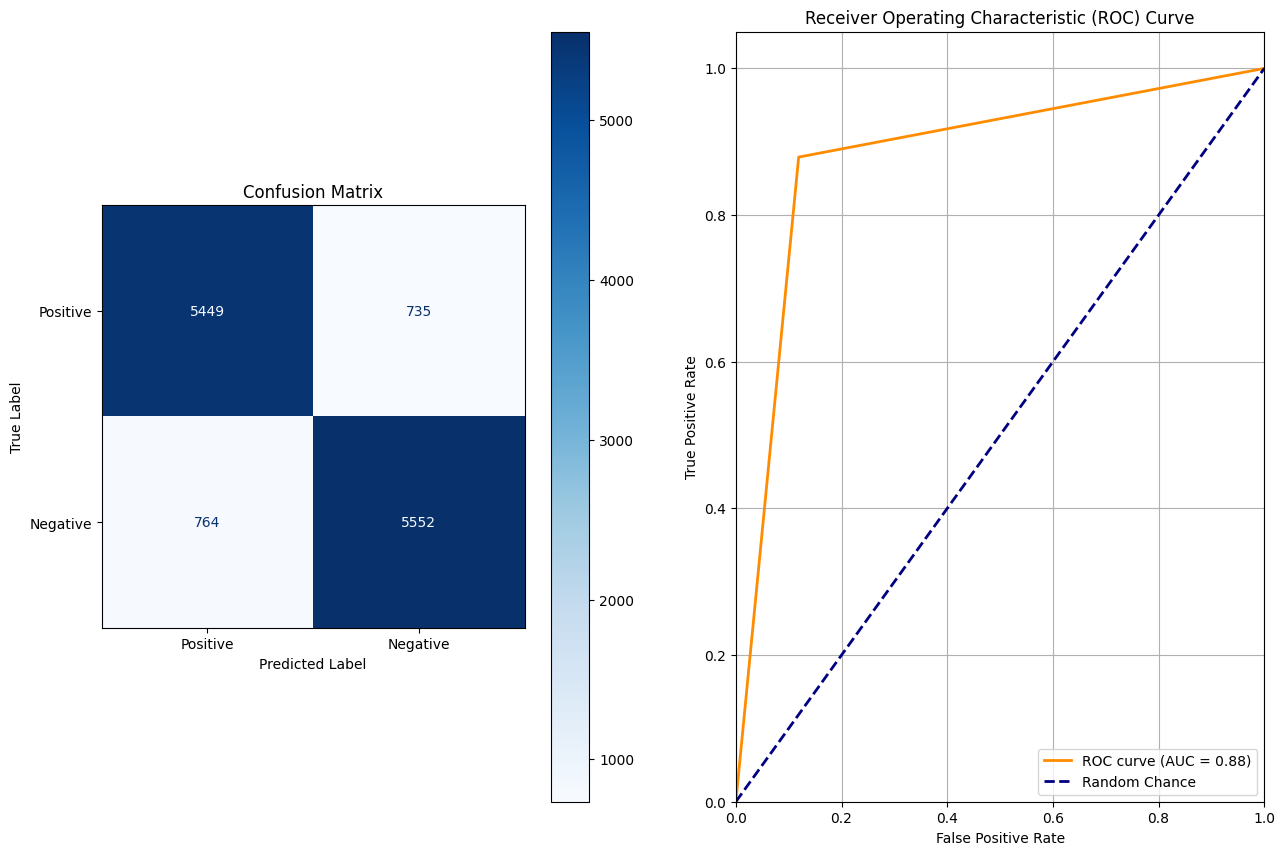

In [85]:
tuned_glove_eval = ModelEvaluator(glove_classifier_with_tuned_embeddings)

tuned_glove_eval.eval_model(novel_padded_sequences, novel_y, labels=["Positive", "Negative"])

In [87]:
from tensorflow.keras import layers

The book uses an LSTM model for this task, so I want to see how it performs relative to my CNN approach. I strayed away from this at first due to the training time, but I have a few hours to let this train now that I finished the rest of the assignment.

In [100]:
glove_classifier_LSTM_with_tuned_embeddings = Sequential([
    # The input for a given review will be a 2D array comprised of the embeddings for each token.
    Input(shape=(max_length,)),
    Embedding(input_dim=input_dim,
              output_dim=vector_len, 
              weights=tuned_embeddings.layers[0].get_weights()[0],
              input_length=max_length, 
              trainable=False),   
    layers.Bidirectional(layers.LSTM(64)),
    layers.BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
glove_classifier_LSTM_with_tuned_embeddings.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

In [101]:
glove_classifier_LSTM_with_tuned_embeddings.fit(
    X_data,
    y_data,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2,
    callbacks=callbacks
)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 198s 210ms/step - accuracy: 0.8320 - loss: 0.3836 - val_accuracy: 0.8660 - val_loss: 0.3307 - learning_rate: 0.0010
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 196s 209ms/step - accuracy: 0.9010 - loss: 0.2554 - val_accuracy: 0.8792 - val_loss: 0.3048 - learning_rate: 0.0010
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 195s 208ms/step - accuracy: 0.9116 - loss: 0.2306 - val_accuracy: 0.8841 - val_loss: 0.2848 - learning_rate: 0.0010
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9218 - loss: 0.2096
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
938/938 ━━━━━━━━━━━━━━━━━━━━ 195s 208ms/step - accuracy: 0.9178 - loss: 0.2142 - val_accuracy: 0.8809 - val_loss: 0.2893 - learning_rate: 0.0010
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 196s 209ms/step - accuracy: 0.9254 - loss: 0.1960 - val_accuracy: 0.8895 - val_loss: 0.2814 - learning_rate: 1.0000e-04
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 191s 204ms/step 

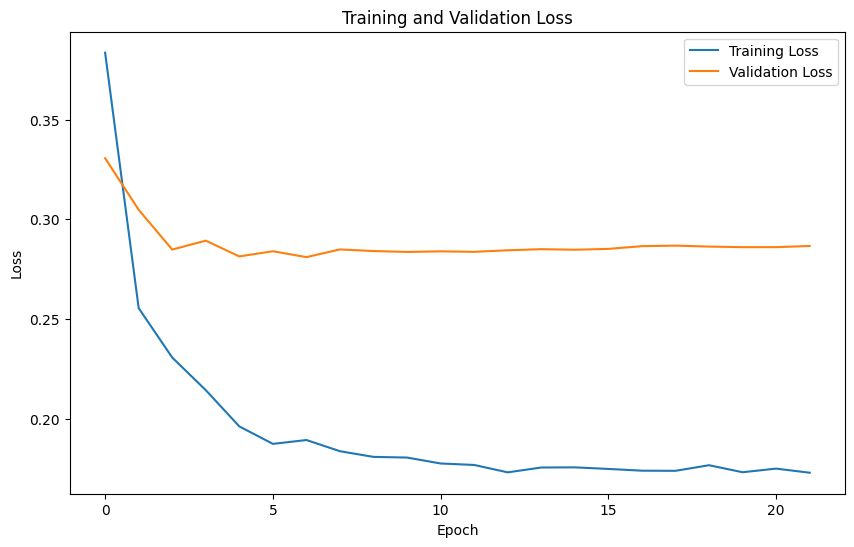

In [102]:
# Get training and validation loss values
train_loss = glove_classifier_LSTM_with_tuned_embeddings.history.history['loss']
# If you included validation data, get validation loss as well
val_loss = glove_classifier_LSTM_with_tuned_embeddings.history.history['val_loss']

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

Significant validation loss plateau.

In [103]:
test_loss, test_acc = glove_classifier_LSTM_with_tuned_embeddings.evaluate(novel_padded_sequences, novel_y)

391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.8946 - loss: 0.2710


391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step
Number of Negative Predictions: 6233
Number of Positive Predictions: 6267
Percent Negative Predictions: 49.864000000000004
Percent Positive Predictions: 50.136

Accuracy: 89.46%

Recall: 0.8891703609879671

Precision: 0.9010107492379271

F1-Score: 0.90


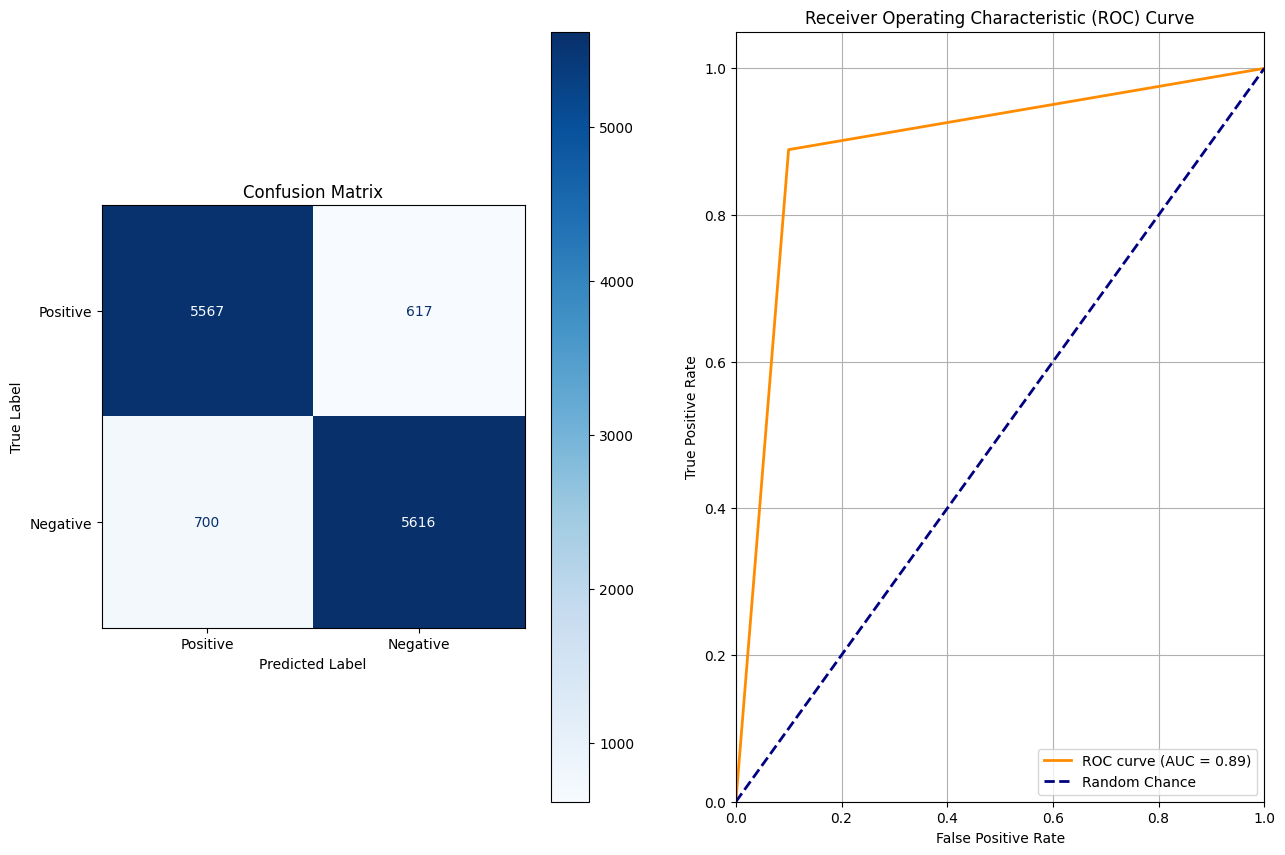

In [104]:
tuned_glove_LSTM_eval = ModelEvaluator(glove_classifier_LSTM_with_tuned_embeddings)

tuned_glove_LSTM_eval.eval_model(novel_padded_sequences, novel_y, labels=["Positive", "Negative"])

The LSTM model produced nearly the same accuracy as the convolutional model despite training for 140x longer. That is a win for the CNN in my book.

#### Based on the lecture theory, why might Skip-Gram (local context) perform differently than GloVe (global statistics) on a sentiment task? Document the training time for both models.

The Word2Vec models performed better on the base embeddings than GloVe. I suspect this is a result of sentiment being dependent on local context of words, which the skip-gram architecture selects for. After fine-tuning the GloVe embeddings, it produced an accuracy of 88%, which is nearly identical to the 89% accuracy of the word2vec model with untuned embeddings. The model architecture between the two embedding methods was kept identical, and the training time was about 6x faster on the GloVe model. This was simply because the GloVe model converged faster than the Word2Vec model, which I suspect is a result of the smaller embedding matrix and better IMDB vocabulary coverage.